# Iteration 4 — combos in the training set

Same `BaselineCNN`, same crop pipeline (`augment=True`). Two changes vs iteration 2/3:

1. `labels.csv` now has **525 combo images in the train split** (generated by
   `generate_combos.py --n-train 525`, train scenes only). The model now sees
   defects stacked during training, which iterations 2/3 showed it couldn't
   calibrate for on its own.
2. **15 epochs** instead of 10 (every prior run was still improving at epoch 10).

Then per-class threshold tuning on validation, as in iteration 3.

Target to beat (crop, tuned): **val macro-F1 0.876 (all) / 0.684 (combo)**, and
especially **combo noise F1 ~0.36**.
Test split is not touched.

In [11]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("working dir:", Path.cwd())

import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from dataset import build_dataloaders
from model import BaselineCNN
from metrics import (evaluate_model, compute_metrics, print_metrics,
                     tune_thresholds, combo_mask, DEFECT_COLUMNS)

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

working dir: c:\Users\Shamik\Desktop\ImageQuality_Classifier\ImageQuality_Classifier
device: cuda


## 1. Data — crop pipeline, train split now includes 525 combos

In [12]:
loaders = build_dataloaders(batch_size=32, augment=True)
for name, ldr in loaders.items():
    df = ldr.dataset.df
    n_combo = int(df["filename"].str.contains("_combo_").sum())
    print(f"{name:5s} {len(df):5d} images ({n_combo} combos) | {len(ldr):3d} batches")

train  3675 images (525 combos) | 115 batches
val     722 images (50 combos) |  23 batches
test    728 images (50 combos) |  23 batches


## 2. Model, loss, optimizer (unchanged)

In [13]:
model = BaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

8,777,797 parameters


## 3. Training helper (unchanged)

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, n_batches = 0.0, 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        n_batches += 1
    return running_loss / n_batches

## 4. Epoch loop (15 epochs)

In [15]:
NUM_EPOCHS = 15
CKPT_PATH = Path("models/traincombo_best.pt")
CKPT_PATH.parent.mkdir(exist_ok=True)

history = []
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, device)

    y_true, y_prob, val_loss = evaluate_model(model, loaders["val"], device, criterion)
    vm = compute_metrics(y_true, y_prob)
    val_f1 = vm["macro_f1"]

    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_macro_f1": val_f1}
    for c in DEFECT_COLUMNS:
        row[f"f1_{c}"] = vm["per_class"][c]["f1"]
    history.append(row)

    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        flag = "  <- saved (best so far)"

    print(f"epoch {epoch:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
          f"| val_macro_f1 {val_f1:.3f}{flag}")

print(f"\nbest val macro-F1: {best_val_f1:.3f}  ->  {CKPT_PATH}")

epoch  1 | train_loss 0.3808 | val_loss 0.2782 | val_macro_f1 0.651  <- saved (best so far)
epoch  2 | train_loss 0.2721 | val_loss 0.2556 | val_macro_f1 0.743  <- saved (best so far)
epoch  3 | train_loss 0.2479 | val_loss 0.2197 | val_macro_f1 0.778  <- saved (best so far)
epoch  4 | train_loss 0.2071 | val_loss 0.1801 | val_macro_f1 0.827  <- saved (best so far)
epoch  5 | train_loss 0.1886 | val_loss 0.1954 | val_macro_f1 0.809
epoch  6 | train_loss 0.1786 | val_loss 0.1585 | val_macro_f1 0.849  <- saved (best so far)
epoch  7 | train_loss 0.1553 | val_loss 0.1607 | val_macro_f1 0.845
epoch  8 | train_loss 0.1425 | val_loss 0.1435 | val_macro_f1 0.870  <- saved (best so far)
epoch  9 | train_loss 0.1430 | val_loss 0.1485 | val_macro_f1 0.873  <- saved (best so far)
epoch 10 | train_loss 0.1235 | val_loss 0.1175 | val_macro_f1 0.901  <- saved (best so far)
epoch 11 | train_loss 0.1060 | val_loss 0.1356 | val_macro_f1 0.885
epoch 12 | train_loss 0.0909 | val_loss 0.1485 | val_macro_f

In [16]:
hist = pd.DataFrame(history)
hist.to_csv("models/traincombo_history.csv", index=False)
hist

,epoch,train_loss,val_loss,val_macro_f1,f1_blur,f1_underexposed,f1_overexposed,f1_noise,f1_contrast
0,1,0.380824,0.278236,0.650646,0.521073,0.868421,0.821429,0.264151,0.778157
1,2,0.272077,0.255642,0.743344,0.735178,0.894309,0.777429,0.486275,0.823529
2,3,0.247860,0.219655,0.777970,0.706977,0.900344,0.834783,0.700965,0.746781
3,4,0.207086,0.180086,0.826733,0.801619,0.945455,0.839827,0.729970,0.816794
4,5,0.188590,0.195383,0.809084,0.694960,0.921260,0.857143,0.734513,0.837545
5,6,0.178602,0.158461,0.849119,0.791667,0.958801,0.852113,0.765823,0.877193
6,7,0.155267,0.160701,0.844581,0.837398,0.914980,0.844444,0.778626,0.847458
7,8,0.142509,0.143541,0.869636,0.848057,0.963235,0.896000,0.775641,0.865248
8,9,0.142971,0.148537,0.872657,0.840816,0.961240,0.899225,0.784810,0.877193
9,10,0.123459,0.117501,0.900887,0.900763,0.981132,0.860215,0.875000,0.887324


## 5. Diagnostics

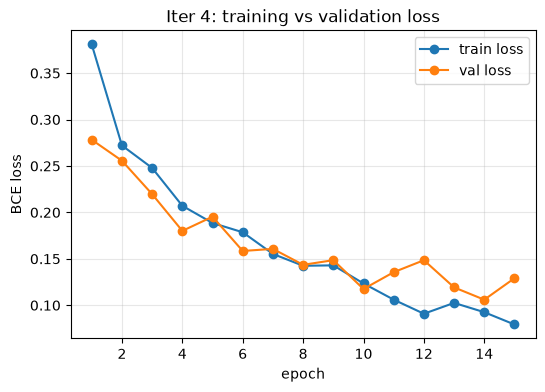

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Iter 4: training vs validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

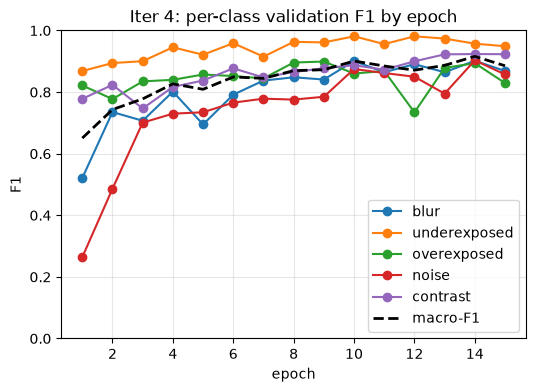

In [18]:
plt.figure(figsize=(6, 4))
for c in DEFECT_COLUMNS:
    plt.plot(hist["epoch"], hist[f"f1_{c}"], marker="o", label=c)
plt.plot(hist["epoch"], hist["val_macro_f1"], "k--", linewidth=2, label="macro-F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.title("Iter 4: per-class validation F1 by epoch")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1); plt.show()

## 6. Evaluate best checkpoint — 0.5 vs tuned, all vs combo

In [19]:
best_model = BaselineCNN().to(device)
best_model.load_state_dict(torch.load(CKPT_PATH, weights_only=True))

y_true, y_prob, _ = evaluate_model(best_model, loaders["val"], device)
cmask = combo_mask(loaders["val"].dataset.df["filename"].values)

thr = tune_thresholds(y_true, y_prob)
print("tuned thresholds:", dict(zip(DEFECT_COLUMNS, thr.round(2))))

print_metrics(compute_metrics(y_true, y_prob),                       "ITER4 VAL all   | 0.5")
print_metrics(compute_metrics(y_true, y_prob, threshold=thr),        "ITER4 VAL all   | tuned")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask]),         "ITER4 VAL combo | 0.5")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr), "ITER4 VAL combo | tuned")

tuned thresholds: {'blur': np.float64(0.55), 'underexposed': np.float64(0.25), 'overexposed': np.float64(0.5), 'noise': np.float64(0.5), 'contrast': np.float64(0.75)}

=== ITER4 VAL all   | 0.5 ===
macro-F1 0.916 | macro-P 0.915 | macro-R 0.918 | subset-acc 0.853
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.912   0.892  0.902   0.968   124    12    15   571
underexposed    0.984   0.932  0.957   0.996   123     2     9   588
overexposed     0.881   0.908  0.894   0.951   118    16    12   576
noise           0.900   0.906  0.903   0.934   126    14    13   569
contrast        0.899   0.950  0.924   0.955   133    15     7   567

=== ITER4 VAL all   | tuned ===
macro-F1 0.922 | macro-P 0.921 | macro-R 0.924 | subset-acc 0.867
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.925   0.892  0.908   0.968   124    10    15   573
underexposed    0.970   0.985  0.977   0.996   130     4     2   586
overexposed     

## 7. Comparison table

Prior best (iteration 3, crop + tuned): macro-F1 **0.876** all / **0.684** combo,
combo noise F1 **~0.36**.

In [20]:
m_all_t   = compute_metrics(y_true, y_prob, threshold=thr)
m_combo_t = compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr)

pd.DataFrame([
    {"metric": "macro-F1 all (tuned)",     "iter3_crop": 0.876, "iter4_traincombo": round(m_all_t["macro_f1"], 3)},
    {"metric": "macro-F1 combo (tuned)",   "iter3_crop": 0.684, "iter4_traincombo": round(m_combo_t["macro_f1"], 3)},
    {"metric": "noise F1 all (tuned)",     "iter3_crop": 0.746, "iter4_traincombo": round(m_all_t["per_class"]["noise"]["f1"], 3)},
    {"metric": "noise F1 combo (tuned)",   "iter3_crop": 0.364, "iter4_traincombo": round(m_combo_t["per_class"]["noise"]["f1"], 3)},
]).set_index("metric")

,iter3_crop,iter4_traincombo
metric,,
macro-F1 all (tuned),0.876,0.922
macro-F1 combo (tuned),0.684,0.888
noise F1 all (tuned),0.746,0.903
noise F1 combo (tuned),0.364,0.851


## 8. FINAL: test set — run once, at the very end

Freeze the checkpoint AND the tuned thresholds first. Not now.

In [21]:
# FINAL numbers. Frozen config: models/traincombo_best.pt + threshold 0.5 for every class.
# (Tuned thresholds shown underneath for reference only - they are NOT the frozen choice.)
y_true, y_prob, _ = evaluate_model(best_model, loaders["test"], device)
cmask = combo_mask(loaders["test"].dataset.df["filename"].values)

print_metrics(compute_metrics(y_true, y_prob),                       "ITER4 TEST all   | threshold 0.5  (FINAL)")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask]),         "ITER4 TEST combo | threshold 0.5  (FINAL)")

print("\n--- for reference only, tuned thresholds ---")
print_metrics(compute_metrics(y_true, y_prob, threshold=thr),               "ITER4 TEST all   | tuned (reference)")
print_metrics(compute_metrics(y_true[cmask], y_prob[cmask], threshold=thr), "ITER4 TEST combo | tuned (reference)")


=== ITER4 TEST all   | threshold 0.5  (FINAL) ===
macro-F1 0.911 | macro-P 0.906 | macro-R 0.918 | subset-acc 0.860
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.933   0.900  0.916   0.977   126     9    14   579
underexposed    0.894   0.969  0.930   0.969   126    15     4   583
overexposed     0.882   0.902  0.892   0.955   120    16    13   579
noise           0.834   0.852  0.843   0.938   121    24    21   562
contrast        0.985   0.964  0.975   0.995   135     2     5   586

=== ITER4 TEST combo | threshold 0.5  (FINAL) ===
macro-F1 0.883 | macro-P 0.976 | macro-R 0.813 | subset-acc 0.600
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.952   0.741  0.833   0.956    20     1     7    22
underexposed    1.000   0.941  0.970   1.000    16     0     1    33
overexposed     1.000   0.700  0.824   1.000    14     0     6    30
noise           1.000   0.759  0.863   0.989    22     0     7    21
contras